# Step 2 — EDA & Dataset Preparation
**Project:** SDG Mapping for PhD Thesis  
**Purpose:** Explore both datasets visually, check class imbalance, and produce the final 80/20 train-test split  
**Inputs:** `data/clean/osdg_clean.csv` · `data/clean/mahe_corpus.csv`  
**Outputs:** `data/clean/X_train.csv` · `data/clean/X_test.csv` · `data/clean/y_train.csv` · `data/clean/y_test.csv`  

> Run cells top to bottom. All plots save to `data/plots/`.


In [1]:
# Cell 1: Install dependencies 
!pip install pandas numpy matplotlib seaborn scikit-learn wordcloud


In [2]:
# Cell 2: Imports & setup 
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from wordcloud import WordCloud
from IPython.display import display

warnings.filterwarnings("ignore")

# Folders
CLEAN_DIR = Path("data/clean")
PLOT_DIR  = Path("data/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Load metadata
with open("data/step1_meta.json") as f:
    meta = json.load(f)

SDG_NAMES = {int(k): v for k, v in meta["sdg_names"].items()}
SDG_SHORT = {
    1:"No Poverty", 2:"Zero Hunger", 3:"Good Health",
    4:"Quality Edu", 5:"Gender Equality", 6:"Clean Water",
    7:"Clean Energy", 8:"Decent Work", 9:"Innovation",
    10:"Reduced Ineq", 11:"Sust. Cities", 12:"Resp. Consump",
    13:"Climate Action", 14:"Life Below Water", 15:"Life on Land",
    16:"Peace & Justice", 17:"Partnerships"
}

print("✅ Imports complete")
print(f"   Plots will save to: {PLOT_DIR.resolve()}")


✅ Imports complete
   Plots will save to: C:\Users\Pranam Acharya\Projects\DL\data\plots


In [3]:
# Cell 3: Load datasets 
df_osdg = pd.read_csv(CLEAN_DIR / "osdg_clean.csv")
df_mahe = pd.read_csv(CLEAN_DIR / "mahe_corpus.csv")

# Basic info
print("=== OSDG Training Dataset ===")
print(f"Shape       : {df_osdg.shape}")
print(f"Columns     : {list(df_osdg.columns)}")
print(f"SDGs present: {sorted(df_osdg['sdg'].unique())}")
print()
print("=== MAHE Application Corpus ===")
print(f"Shape       : {df_mahe.shape}")
print(f"Columns     : {list(df_mahe.columns)}")
print()
display(df_osdg.head(3))
display(df_mahe.head(3))


=== OSDG Training Dataset ===
Shape       : (34005, 4)
Columns     : ['text', 'sdg', 'sdg_name', 'source']
SDGs present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]

=== MAHE Application Corpus ===
Shape       : (854, 6)
Columns     : ['text', 'sdg', 'sdg_name', 'source', 'title', 'url']



,text,sdg,sdg_name,source
0,"From a gender perspective, Paulgaard points ou...",5,Gender Equality,osdg
1,The average figure also masks large difference...,3,Good Health and Well-Being,osdg
2,Applied research is directed “primarily toward...,9,"Industry, Innovation and Infrastructure",osdg


,text,sdg,sdg_name,source,title,url
0,Analytical and bioanalytical HPLC method for s...,NaN,NaN,mahe,Analytical and bioanalytical HPLC method for s...,https://researcher.manipal.edu/en/publications...
1,‘Solving’ as a key course learning outcome (CL...,NaN,NaN,mahe,‘Solving’ as a key course learning outcome (CL...,https://researcher.manipal.edu/en/publications...
2,Remote Sensing: A Satellite-Based Advanced Geo...,NaN,NaN,mahe,Remote Sensing: A Satellite-Based Advanced Geo...,https://researcher.manipal.edu/en/publications...


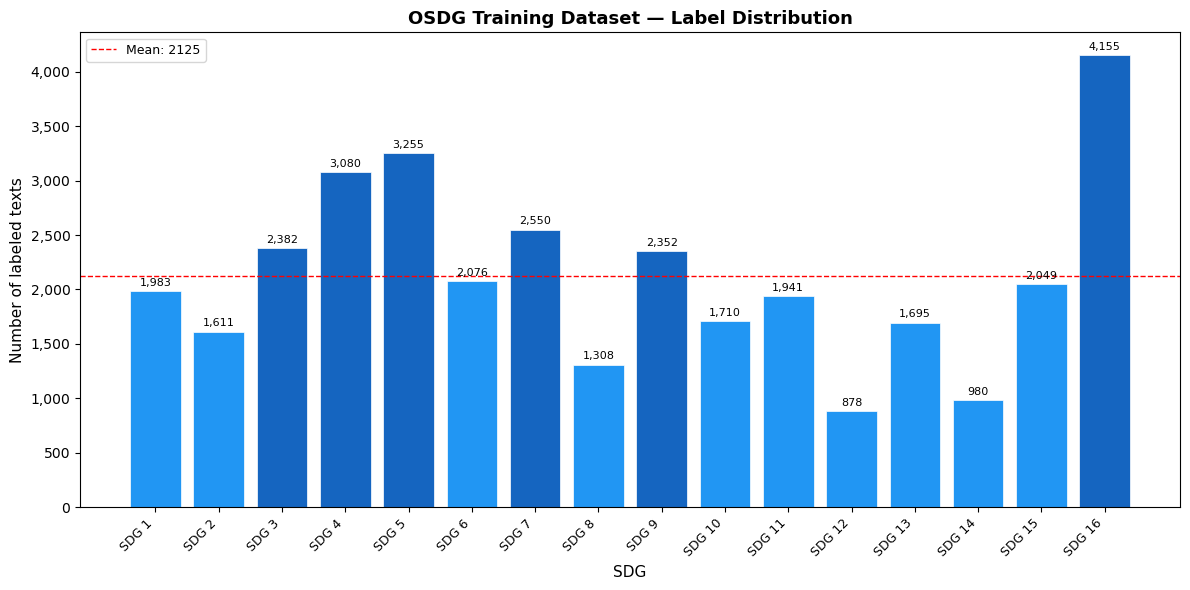


Imbalance ratio : 4.7x
Most common     : SDG 16 (Peace, Justice and Strong Institutions) — 4,155
Least common    : SDG 12 (Responsible Consumption and Production) — 878
SDG 17 present  : False (missing from this OSDG version — expected)


In [4]:
# Cell 4: SDG label distribution 
fig, ax = plt.subplots(figsize=(12, 6))

dist = df_osdg["sdg"].value_counts().sort_index()
colors = ["#2196F3" if v < dist.mean() else "#1565C0" for v in dist.values]

bars = ax.bar(
    [f"SDG {i}" for i in dist.index],
    dist.values,
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

# Value labels on bars
for bar, val in zip(bars, dist.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{val:,}",
        ha="center", va="bottom", fontsize=8
    )

ax.axhline(dist.mean(), color="red", linestyle="--", linewidth=1, label=f"Mean: {dist.mean():.0f}")
ax.set_xlabel("SDG", fontsize=11)
ax.set_ylabel("Number of labeled texts", fontsize=11)
ax.set_title("OSDG Training Dataset — Label Distribution", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xticklabels([f"SDG {i}" for i in dist.index], rotation=45, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(PLOT_DIR / "01_sdg_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nImbalance ratio : {dist.max() / dist.min():.1f}x")
print(f"Most common     : SDG {dist.idxmax()} ({SDG_NAMES[dist.idxmax()]}) — {dist.max():,}")
print(f"Least common    : SDG {dist.idxmin()} ({SDG_NAMES[dist.idxmin()]}) — {dist.min():,}")
print(f"SDG 17 present  : {17 in dist.index} (missing from this OSDG version — expected)")


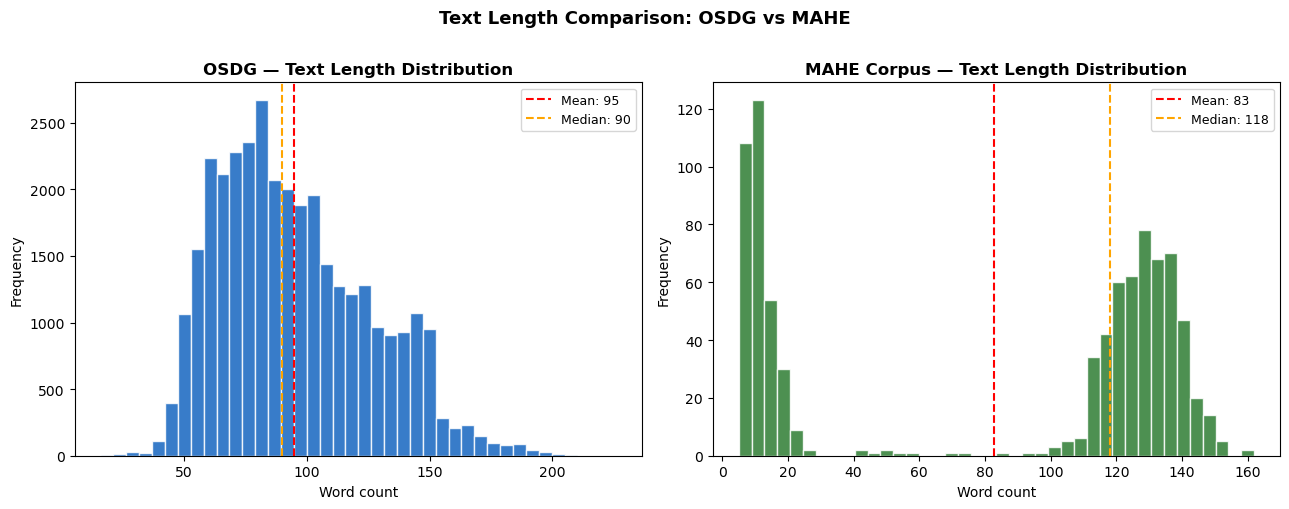

OSDG text length stats:
count    34005.0
mean        94.8
std         30.9
min         16.0
25%         71.0
50%         90.0
75%        116.0
max        226.0

MAHE text length stats:
count    854.0
mean      82.8
std       57.7
min        5.0
25%       12.0
50%      118.0
75%      131.0
max      162.0


In [5]:
# Cell 5: Text length distribution 
df_osdg["word_count"] = df_osdg["text"].str.split().str.len()
df_mahe["word_count"]  = df_mahe["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# OSDG
axes[0].hist(df_osdg["word_count"], bins=40, color="#1565C0", edgecolor="white", alpha=0.85)
axes[0].axvline(df_osdg["word_count"].mean(), color="red", linestyle="--",
                label=f"Mean: {df_osdg['word_count'].mean():.0f}")
axes[0].axvline(df_osdg["word_count"].median(), color="orange", linestyle="--",
                label=f"Median: {df_osdg['word_count'].median():.0f}")
axes[0].set_title("OSDG — Text Length Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Word count", fontsize=10)
axes[0].set_ylabel("Frequency", fontsize=10)
axes[0].legend(fontsize=9)

# MAHE
axes[1].hist(df_mahe["word_count"], bins=40, color="#2E7D32", edgecolor="white", alpha=0.85)
axes[1].axvline(df_mahe["word_count"].mean(), color="red", linestyle="--",
                label=f"Mean: {df_mahe['word_count'].mean():.0f}")
axes[1].axvline(df_mahe["word_count"].median(), color="orange", linestyle="--",
                label=f"Median: {df_mahe['word_count'].median():.0f}")
axes[1].set_title("MAHE Corpus — Text Length Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Word count", fontsize=10)
axes[1].set_ylabel("Frequency", fontsize=10)
axes[1].legend(fontsize=9)

plt.suptitle("Text Length Comparison: OSDG vs MAHE", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / "02_text_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("OSDG text length stats:")
print(df_osdg["word_count"].describe().round(1).to_string())
print("\nMAHE text length stats:")
print(df_mahe["word_count"].describe().round(1).to_string())


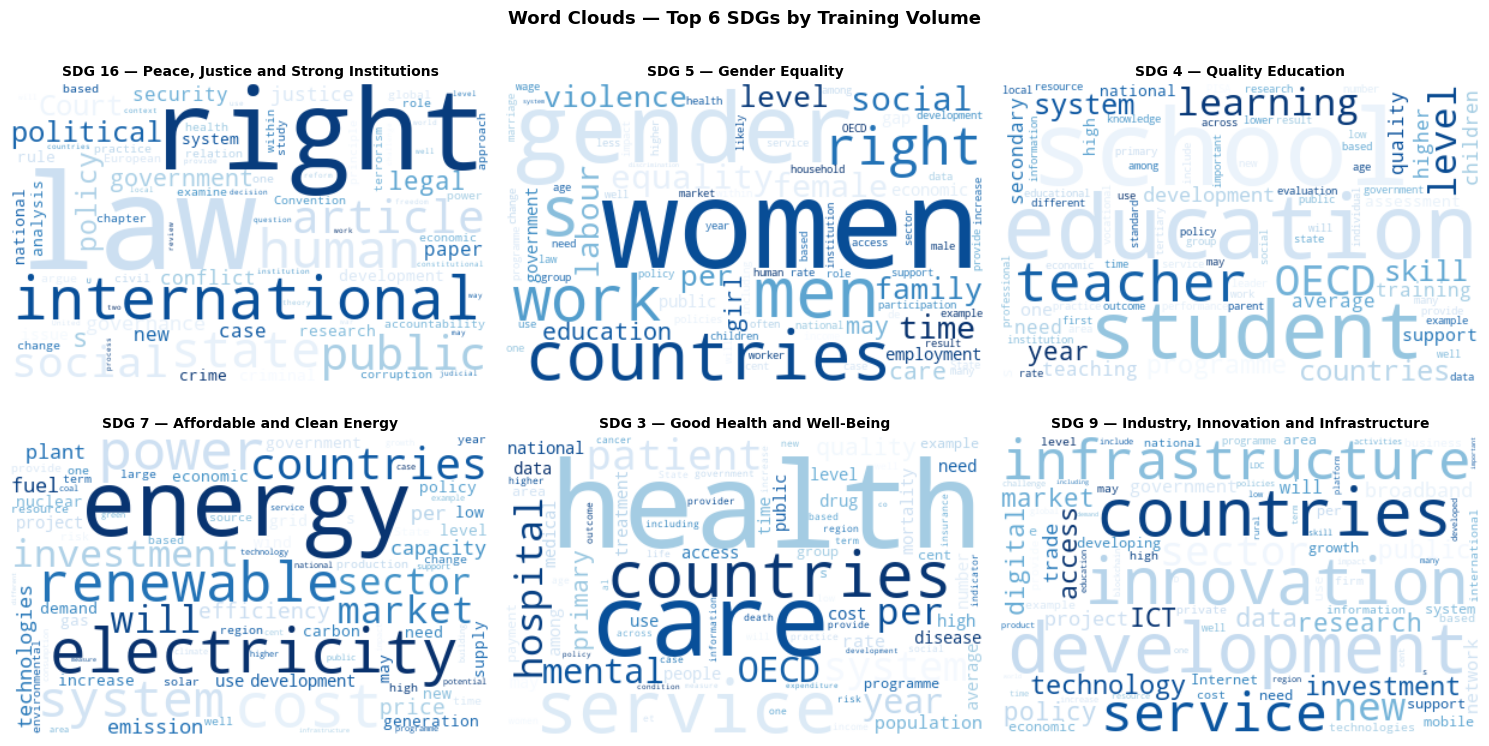

✅ Word clouds saved


In [6]:
# Cell 6: Word clouds per SDG (top 6 SDGs by size) 
top_sdgs = df_osdg["sdg"].value_counts().head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, sdg in enumerate(top_sdgs):
    texts = " ".join(df_osdg[df_osdg["sdg"] == sdg]["text"].tolist())
    wc = WordCloud(
        width=400, height=250,
        background_color="white",
        colormap="Blues",
        max_words=80,
        stopwords=None,
        collocations=False
    ).generate(texts)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].axis("off")
    axes[idx].set_title(f"SDG {sdg} — {SDG_NAMES.get(sdg, '')}", fontsize=10, fontweight="bold")

plt.suptitle("Word Clouds — Top 6 SDGs by Training Volume", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_wordclouds_top6_sdgs.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Word clouds saved")


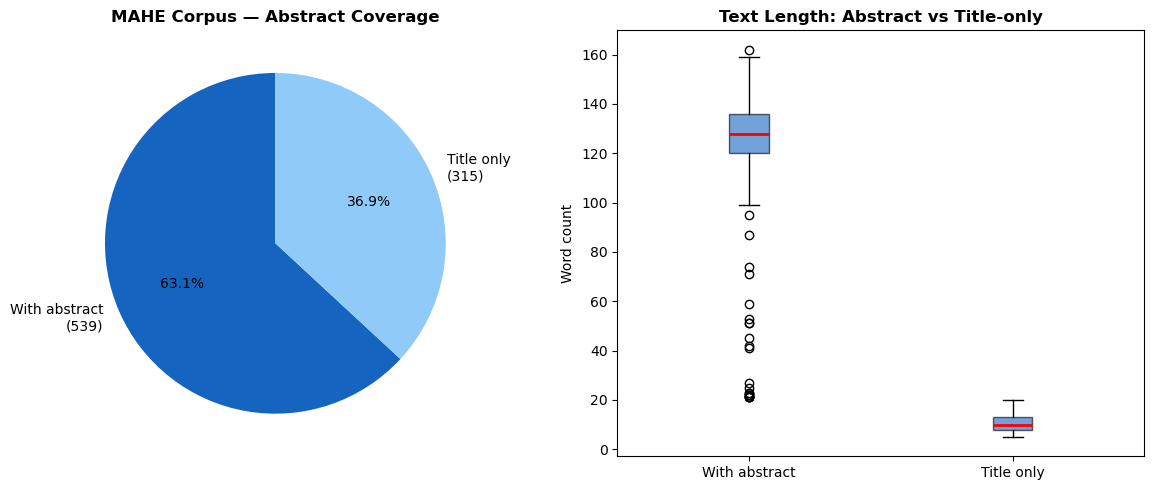

With abstract   : 539 (63.1%)
Title only      : 315 (36.9%)


In [7]:
# Cell 7: MAHE corpus — text length by abstract availability 
df_mahe["has_abstract"] = df_mahe["text"].str.split().str.len() > 20

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
counts = df_mahe["has_abstract"].value_counts()
labels = [f"With abstract\n({counts.get(True,0):,})",
          f"Title only\n({counts.get(False,0):,})"]
axes[0].pie(counts.values, labels=labels, autopct="%1.1f%%",
            colors=["#1565C0", "#90CAF9"], startangle=90,
            textprops={"fontsize": 10})
axes[0].set_title("MAHE Corpus — Abstract Coverage", fontsize=12, fontweight="bold")

# Box plot comparison
data_with    = df_mahe[df_mahe["has_abstract"] == True]["word_count"]
data_without = df_mahe[df_mahe["has_abstract"] == False]["word_count"]
axes[1].boxplot(
    [data_with, data_without],
    labels=["With abstract", "Title only"],
    patch_artist=True,
    boxprops=dict(facecolor="#1565C0", alpha=0.6),
    medianprops=dict(color="red", linewidth=2)
)
axes[1].set_title("Text Length: Abstract vs Title-only", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Word count", fontsize=10)

plt.tight_layout()
plt.savefig(PLOT_DIR / "04_mahe_abstract_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"With abstract   : {counts.get(True,0):,} ({counts.get(True,0)/len(df_mahe)*100:.1f}%)")
print(f"Title only      : {counts.get(False,0):,} ({counts.get(False,0)/len(df_mahe)*100:.1f}%)")


In [8]:
# Cell 8: Class imbalance — handling strategy 
dist = df_osdg["sdg"].value_counts().sort_index()
mean_count = dist.mean()

print("=== Class Imbalance Analysis ===")
print(f"Mean examples per SDG : {mean_count:.0f}")
print(f"Imbalance ratio       : {dist.max()/dist.min():.1f}x")
print()
print("Recommended strategy  : class_weight='balanced' in all classifiers")
print("This automatically gives higher weight to minority SDGs during training.")
print()
print("SDGs below mean (will benefit from balancing):")
for sdg, count in dist.items():
    if count < mean_count:
        diff = mean_count - count
        print(f"  SDG {int(sdg):2d} ({SDG_NAMES[int(sdg)]:<45}) : {count:,} ({diff:.0f} below mean)")

print()
print("Note: SDG 17 is missing from this OSDG version.")
print("Similarity scoring in Step 6 will still cover SDG 17")
print("using the official UN SDG 17 target texts as reference profile.")


=== Class Imbalance Analysis ===
Mean examples per SDG : 2125
Imbalance ratio       : 4.7x

Recommended strategy  : class_weight='balanced' in all classifiers
This automatically gives higher weight to minority SDGs during training.

SDGs below mean (will benefit from balancing):
  SDG  1 (No Poverty                                   ) : 1,983 (142 below mean)
  SDG  2 (Zero Hunger                                  ) : 1,611 (514 below mean)
  SDG  6 (Clean Water and Sanitation                   ) : 2,076 (49 below mean)
  SDG  8 (Decent Work and Economic Growth              ) : 1,308 (817 below mean)
  SDG 10 (Reduced Inequalities                         ) : 1,710 (415 below mean)
  SDG 11 (Sustainable Cities and Communities           ) : 1,941 (184 below mean)
  SDG 12 (Responsible Consumption and Production       ) : 878 (1247 below mean)
  SDG 13 (Climate Action                               ) : 1,695 (430 below mean)
  SDG 14 (Life Below Water                             ) : 980 (11

In [9]:
# Cell 9: Train-test split (80/20) 
# This split is on OSDG data only.
# MAHE corpus is never used for training — it is the application target.

X = df_osdg["text"].reset_index(drop=True)
y = df_osdg["sdg"].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ensures each SDG has proportional train/test representation
)

print("=== Train-Test Split ===")
print(f"Training set   : {len(X_train):,} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set       : {len(X_test):,}  samples ({len(X_test)/len(X)*100:.0f}%)")
print()

# Verify stratification
train_dist = y_train.value_counts().sort_index()
test_dist  = y_test.value_counts().sort_index()

print("Stratification check (train% vs test% per SDG):")
print(f"{'SDG':<8} {'Train':>8} {'Test':>8} {'Train%':>8} {'Test%':>8}")
print("-" * 44)
for sdg in sorted(y.unique()):
    tr = train_dist.get(sdg, 0)
    te = test_dist.get(sdg, 0)
    tr_pct = tr / len(y_train) * 100
    te_pct = te / len(y_test)  * 100
    print(f"SDG {int(sdg):<4} {tr:>8,} {te:>8,} {tr_pct:>7.1f}% {te_pct:>7.1f}%")


=== Train-Test Split ===
Training set   : 27,204 samples (80%)
Test set       : 6,801  samples (20%)

Stratification check (train% vs test% per SDG):
SDG         Train     Test   Train%    Test%
--------------------------------------------
SDG 1       1,586      397     5.8%     5.8%
SDG 2       1,289      322     4.7%     4.7%
SDG 3       1,906      476     7.0%     7.0%
SDG 4       2,464      616     9.1%     9.1%
SDG 5       2,604      651     9.6%     9.6%
SDG 6       1,661      415     6.1%     6.1%
SDG 7       2,040      510     7.5%     7.5%
SDG 8       1,046      262     3.8%     3.9%
SDG 9       1,882      470     6.9%     6.9%
SDG 10      1,368      342     5.0%     5.0%
SDG 11      1,553      388     5.7%     5.7%
SDG 12        702      176     2.6%     2.6%
SDG 13      1,356      339     5.0%     5.0%
SDG 14        784      196     2.9%     2.9%
SDG 15      1,639      410     6.0%     6.0%
SDG 16      3,324      831    12.2%    12.2%


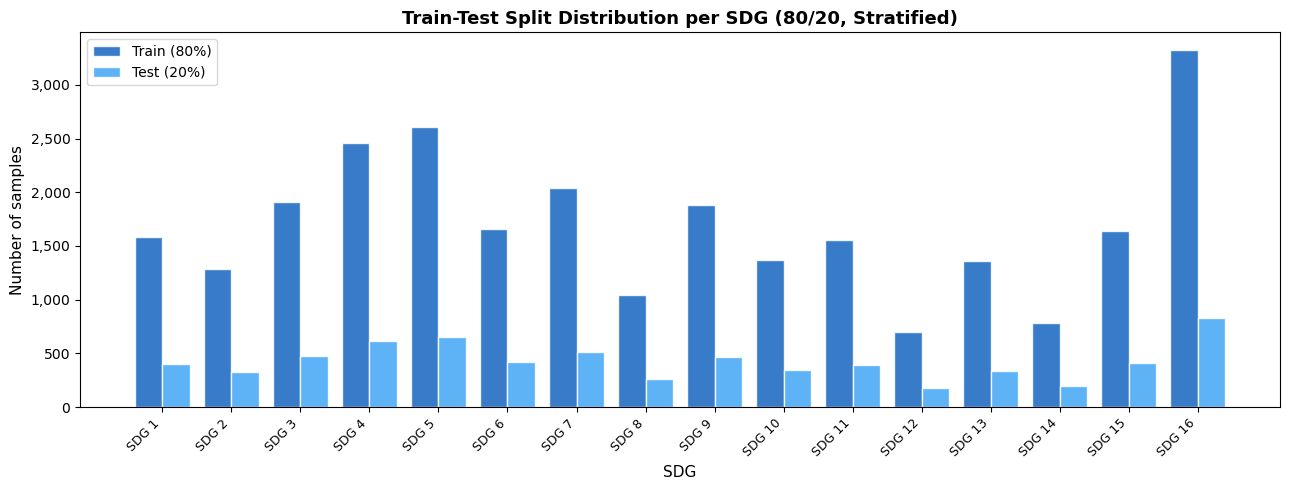

✅ Split visualisation saved


In [10]:
# Cell 10: Visualise train-test split distribution 
fig, ax = plt.subplots(figsize=(13, 5))

x      = np.arange(len(train_dist))
width  = 0.4

ax.bar(x - width/2, train_dist.values, width, label="Train (80%)",
       color="#1565C0", edgecolor="white", alpha=0.85)
ax.bar(x + width/2, test_dist.values,  width, label="Test (20%)",
       color="#42A5F5", edgecolor="white", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f"SDG {int(i)}" for i in train_dist.index],
                   rotation=45, ha="right", fontsize=9)
ax.set_xlabel("SDG", fontsize=11)
ax.set_ylabel("Number of samples", fontsize=11)
ax.set_title("Train-Test Split Distribution per SDG (80/20, Stratified)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(PLOT_DIR / "05_train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Split visualisation saved")


In [11]:
# Cell 11: Save split datasets 
X_train.to_csv(CLEAN_DIR / "X_train.csv", index=False, header=["text"])
X_test.to_csv( CLEAN_DIR / "X_test.csv",  index=False, header=["text"])
y_train.to_csv(CLEAN_DIR / "y_train.csv", index=False, header=["sdg"])
y_test.to_csv( CLEAN_DIR / "y_test.csv",  index=False, header=["sdg"])

print("💾 Saved split datasets:")
print(f"   data/clean/X_train.csv  — {len(X_train):,} rows")
print(f"   data/clean/X_test.csv   — {len(X_test):,} rows")
print(f"   data/clean/y_train.csv  — {len(y_train):,} rows")
print(f"   data/clean/y_test.csv   — {len(y_test):,} rows")

# Update metadata
meta["train_size"]     = len(X_train)
meta["test_size"]      = len(X_test)
meta["split_strategy"] = "stratified 80/20 random_state=42"
meta["sdg_17_note"]    = "Missing from OSDG dataset — covered in Step 6 via SDG reference profiles"
meta["imbalance_fix"]  = "class_weight=balanced in all classifiers"

with open("data/step2_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("\n💾 Saved: data/step2_meta.json")

print("\n✅ Step 2 complete → next: step3_preprocessing.ipynb")


💾 Saved split datasets:
   data/clean/X_train.csv  — 27,204 rows
   data/clean/X_test.csv   — 6,801 rows
   data/clean/y_train.csv  — 27,204 rows
   data/clean/y_test.csv   — 6,801 rows

💾 Saved: data/step2_meta.json

✅ Step 2 complete → next: step3_preprocessing.ipynb


In [12]:
# Cell 12: EDA summary 
print("=" * 60)
print("  STEP 2 — EDA SUMMARY")
print("=" * 60)
print()
print(f"  OSDG training rows     : {len(df_osdg):,}")
print(f"  MAHE application rows  : {len(df_mahe):,}")
print(f"  SDGs in training data  : 16 (SDG 17 missing — known)")
print(f"  Imbalance ratio        : {df_osdg['sdg'].value_counts().max() / df_osdg['sdg'].value_counts().min():.1f}x")
print(f"  Fix                    : class_weight='balanced'")
print()
print(f"  Train split            : {len(X_train):,} samples (80%)")
print(f"  Test split             : {len(X_test):,}  samples (20%)")
print(f"  Split type             : stratified by SDG label")
print()
print(f"  MAHE abstract coverage : {df_mahe['has_abstract'].mean()*100:.1f}%")
print(f"  Avg OSDG text length   : {df_osdg['word_count'].mean():.0f} words")
print(f"  Avg MAHE text length   : {df_mahe['word_count'].mean():.0f} words")
print()
print(f"  Plots saved to         : {PLOT_DIR.resolve()}")
print()
print("  Key insight: MAHE corpus is heavily health-focused (SDG 3).")
print("  Expect high SDG 3 predictions — consistent with MAHE's medical focus.")
print()
print("=" * 60)


  STEP 2 — EDA SUMMARY

  OSDG training rows     : 34,005
  MAHE application rows  : 854
  SDGs in training data  : 16 (SDG 17 missing — known)
  Imbalance ratio        : 4.7x
  Fix                    : class_weight='balanced'

  Train split            : 27,204 samples (80%)
  Test split             : 6,801  samples (20%)
  Split type             : stratified by SDG label

  MAHE abstract coverage : 63.1%
  Avg OSDG text length   : 95 words
  Avg MAHE text length   : 83 words

  Plots saved to         : C:\Users\Pranam Acharya\Projects\DL\data\plots

  Key insight: MAHE corpus is heavily health-focused (SDG 3).
  Expect high SDG 3 predictions — consistent with MAHE's medical focus.

